# Authenticate Google Earth Engine

In [ ]:
import ee
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project='yale-capstone-hab')

pond = ee.Geometry.Point([-73.60508, 42.10069])

In [ ]:
# Load Sentinel-2, growing season, 10% cloud coverage or less
s2 = (ee.ImageCollection('COPERNICUS/S2_SR_HARMONIZED')
    .filterBounds(pond)
    .filterDate('2017-01-01', '2025-12-31')
    .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 10))
    .filter(ee.Filter.calendarRange(5, 10, 'month')))

# Green band ratio: Green / (Red + Green + Blue)
# Higher value = more green light = algae tinting water
def add_greenness(image):

    green = image.select('B3').toFloat()
    red   = image.select('B4').toFloat()
    blue  = image.select('B2').toFloat()

    greenness = green.divide(red.add(green).add(blue)).rename('GREENNESS')
    return image.addBands(greenness).set('date', image.date().format('YYYY-MM-dd'))

s2_green = s2.map(add_greenness)

def extract_green(image):
    val = image.select('GREENNESS').reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=pond.buffer(50),
        scale=10
    ).get('GREENNESS')
    return ee.Feature(None, {'date': image.get('date'), 'GREENNESS': val})

values = s2_green.map(extract_green).getInfo()
rows = [f['properties'] for f in values['features']]
gdf = pd.DataFrame(rows)
gdf['date'] = pd.to_datetime(gdf['date'])
gdf = gdf.dropna().sort_values('date')
gdf['year'] = gdf['date'].dt.year

print(f"Scenes: {len(gdf)}")
print(gdf.head(10))

Scenes: 100
   GREENNESS       date  year
0   0.380861 2017-06-12  2017
1   0.333434 2017-07-02  2017
2   0.341280 2017-07-30  2017
3   0.336178 2017-08-26  2017
4   0.439496 2017-10-03  2017
5   0.432262 2017-10-18  2017
6   0.377428 2018-05-01  2018
7   0.345833 2018-05-11  2018
8   0.337517 2018-05-23  2018
9   0.328219 2018-06-12  2018


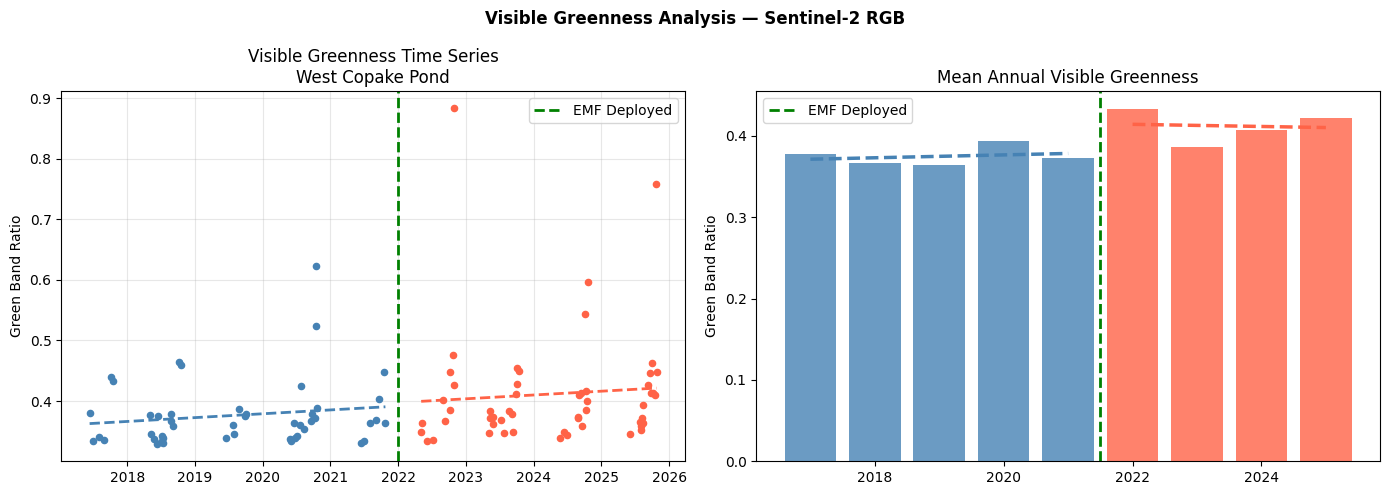

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

pre_g = gdf[gdf['date'] < pd.Timestamp('2022-01-01')]
post_g = gdf[gdf['date'] >= pd.Timestamp('2022-01-01')]

# Plot 1 - Time series with trendlines
for subset, color in [(pre_g, 'steelblue'), (post_g, 'tomato')]:
    axes[0].scatter(subset['date'], subset['GREENNESS'],
                    color=color, s=20, zorder=3)
    z = np.polyfit(subset['date'].astype(np.int64), subset['GREENNESS'], 1)
    p = np.poly1d(z)
    axes[0].plot(subset['date'], p(subset['date'].astype(np.int64)),
                color=color, linewidth=2, linestyle='--')

axes[0].axvline(pd.Timestamp('2022-01-01'), color='green',
                linewidth=2, linestyle='--', label='EMF Deployed')

axes[0].set_title('Visible Greenness Time Series\nChrysler Pond')
axes[0].set_ylabel('Green Band Ratio')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2 - Annual means with trendlines
annual_g = gdf.groupby('year')['GREENNESS'].mean().reset_index()
bar_colors = ['steelblue' if y < 2022 else 'tomato' for y in annual_g['year']]
axes[1].bar(annual_g['year'], annual_g['GREENNESS'], color=bar_colors, alpha=0.8)

# Trendlines on bar chart
pre_ann = annual_g[annual_g['year'] < 2022]
post_ann = annual_g[annual_g['year'] >= 2022]

for subset, color in [(pre_ann, 'steelblue'), (post_ann, 'tomato')]:
    z = np.polyfit(subset['year'], subset['GREENNESS'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(subset['year'].min(), subset['year'].max(), 100)
    axes[1].plot(x_line, p(x_line), color=color, linewidth=2.5, linestyle='--')

axes[1].axvline(2021.5, color='green', linewidth=2, linestyle='--', label='EMF Deployed')
axes[1].set_title('Mean Annual Visible Greenness')
axes[1].set_ylabel('Green Band Ratio')
axes[1].legend()

plt.suptitle('Visible Greenness Analysis - Sentinel-2 RGB', fontweight='bold')
plt.tight_layout()
plt.savefig('visible_greenness.png', dpi=150)
plt.show()

Visible greenness, measured as the ratio of green band reflectance to total visible light from Sentinel-2 imagery, shows a modest but consistent elevation in the post-intervention period (2022–present) relative to the pre-intervention baseline (2017–2021). The post-intervention trendline indicates a gradual increase in water surface greenness over time, suggesting algal presence has not demonstrably declined following EMF device deployment.